# 04 - Stock Optimization

LightGBM tahminlerini temel alarak her **store × item** kombinasyonu için envanter kararları üretilecek.

| Karar Değişkeni | Açıklama |
|-----------------|----------|
| **Safety Stock (SS)** | Talep ve tedarik belirsizliğine karşı tampon stok |
| **Reorder Point (ROP)** | Sipariş verilmesi gereken stok seviyesi |
| **EOQ** | Toplam maliyeti minimize eden sipariş miktarı |
| **Aksiyon** | `CRITICAL / LOW / OK / OVERSTOCK` |

**Girdiler:**
- `data/processed/test_predictions.parquet` — LightGBM günlük tahminleri (2017)

**Çıktı:**
- `data/processed/inventory_recommendations.parquet` — 500 kombinasyon için öneri tablosu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.optimize import minimize_scalar, minimize
from scipy.stats import norm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

PROCESSED_DIR = Path('../data/processed')

# ── Envanter Parametreleri ────────────────────────────────────────
LEAD_TIME_DAYS   = 7       # tedarik süresi (gün)
REVIEW_PERIOD    = 7       # sipariş gözden geçirme periyodu (gün)
SERVICE_LEVEL    = 0.95    # hedef hizmet düzeyi
HOLDING_COST_PCT = 0.20    # yıllık elde tutma maliyeti (%)
ORDERING_COST    = 50.0    # sipariş başına sabit maliyet (TL)
UNIT_COST        = 10.0    # birim ürün maliyeti (TL)
STOCKOUT_COST    = 25.0    # birim stok-dışı kalma maliyeti (TL)
ALPHA            = 0.5     # çok amaçlı opt. maliyet ağırlığı
# ─────────────────────────────────────────────────────────────────

H = HOLDING_COST_PCT * UNIT_COST
Z = norm.ppf(SERVICE_LEVEL)

print(f'Hizmet düzeyi : {SERVICE_LEVEL:.0%}  →  z = {Z:.3f}')
print(f'Lead time     : {LEAD_TIME_DAYS} gün')
print(f'Review period : {REVIEW_PERIOD} gün')
print(f'Holding cost  : {H:.2f} TL/birim/yıl')

Hizmet düzeyi : 95%  →  z = 1.645
Lead time     : 7 gün
Review period : 7 gün
Holding cost  : 2.00 TL/birim/yıl


## 1. Veri Yükleme & Talep İstatistikleri

In [2]:
pred_df = pd.read_parquet(PROCESSED_DIR / 'test_predictions.parquet')
pred_df['date'] = pd.to_datetime(pred_df['date'])

print(f'Tahmin verisi: {pred_df.shape}  ({pred_df.date.min().date()} → {pred_df.date.max().date()})')
pred_df.head()

Tahmin verisi: (182500, 6)  (2017-01-01 → 2017-12-31)


,date,store,item,sales,predicted,error
0,2017-01-01,1,1,19,19.365380,-0.365380
1,2017-01-02,1,1,15,12.357302,2.642698
2,2017-01-03,1,1,10,12.685907,-2.685907
3,2017-01-04,1,1,16,14.066687,1.933313
4,2017-01-05,1,1,14,15.656075,-1.656075


In [3]:
def compute_demand_stats(group):
    """
    Bir store×item grubu için temel talep istatistikleri.
    Gerçek satış + model hatası birlikte kullanılarak belirsizlik modellenir.
    """
    d      = group['sales'].values
    f      = group['predicted'].values
    errors = d - f

    mean_d = d.mean()
    std_d  = d.std(ddof=1)
    rmse   = np.sqrt((errors ** 2).mean())

    # σ_LT = √(L+R) * σ_d  (bağımsız günlük talep)
    std_lt  = np.sqrt(LEAD_TIME_DAYS) * std_d
    std_rlt = np.sqrt(LEAD_TIME_DAYS + REVIEW_PERIOD) * std_d

    return pd.Series({
        'mean_demand_daily'  : mean_d,
        'std_demand_daily'   : std_d,
        'mean_forecast_daily': f.mean(),
        'forecast_rmse'      : rmse,
        'std_lead_time'      : std_lt,
        'std_review_lt'      : std_rlt,
        'total_annual_demand': mean_d * 365,
        'n_days'             : len(d),
    })

stats = (
    pred_df.groupby(['store', 'item'])
           .apply(compute_demand_stats)
           .reset_index()
)

print(f'Talep istatistik tablosu: {stats.shape}')
stats.head()

Talep istatistik tablosu: (500, 10)


,store,item,mean_demand_daily,std_demand_daily,mean_forecast_daily,forecast_rmse,std_lead_time,std_review_lt,total_annual_demand,n_days
0,1,1,22.183562,6.953278,22.491398,4.589659,18.396645,26.016786,8097.0,365.0
1,1,2,59.789041,15.976524,59.636636,7.580744,42.269910,59.778680,21823.0,365.0
2,1,3,37.386301,10.517977,37.357963,6.031860,27.827951,39.354665,13646.0,365.0
3,1,4,22.131507,6.838741,22.383688,4.438469,18.093607,25.588224,8078.0,365.0
4,1,5,18.695890,5.714653,18.920730,4.004411,15.119552,21.382275,6824.0,365.0


## 2. Safety Stock

$$SS = z \cdot \sigma_{d} \cdot \sqrt{L + R}$$

- $z$ : hizmet düzeyi z-skoru  
- $\sigma_d$ : günlük talep standart sapması  
- $L$ : tedarik süresi, $R$ : gözden geçirme periyodu

Safety Stock istatistikleri:
count    500.00
mean      92.82
std       37.37
min       30.73
25%       60.35
50%       89.17
75%      119.06
max      188.83
Name: safety_stock, dtype: float64


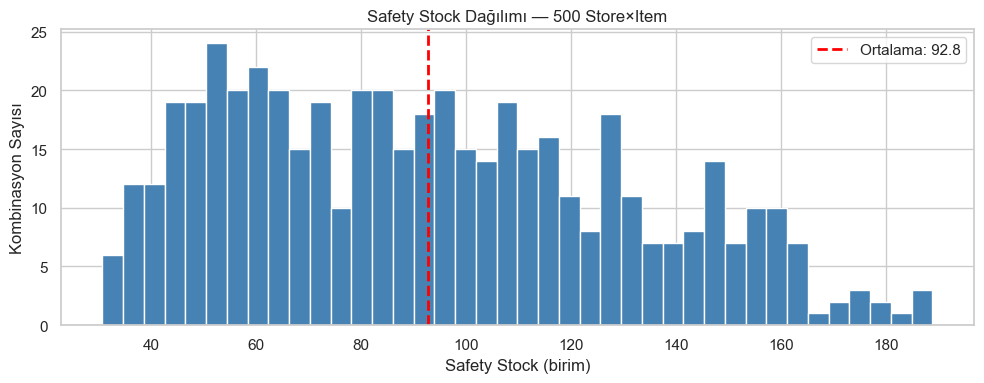

In [4]:
def safety_stock(std_d, z=Z, lead_time=LEAD_TIME_DAYS, review=REVIEW_PERIOD):
    """Safety stock: z * σ_d * √(L + R)"""
    return z * std_d * np.sqrt(lead_time + review)

stats['safety_stock'] = safety_stock(stats['std_demand_daily']).round(2)

print('Safety Stock istatistikleri:')
print(stats['safety_stock'].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats['safety_stock'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(stats['safety_stock'].mean(), color='red', lw=2, linestyle='--',
           label=f'Ortalama: {stats["safety_stock"].mean():.1f}')
ax.set_xlabel('Safety Stock (birim)')
ax.set_ylabel('Kombinasyon Sayısı')
ax.set_title('Safety Stock Dağılımı — 500 Store×Item')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Reorder Point (ROP)

**Statik:** $ROP = \bar{d} \cdot L + SS$

**Dinamik** (LightGBM tahminli): $ROP_{dyn} = \sum_{t=1}^{L} \hat{d}_t + SS$

In [5]:
def compute_dynamic_rop(group, safety_stock_val, lead_time=LEAD_TIME_DAYS):
    """
    Son LEAD_TIME günlük tahmini toplayarak lead-time talebi hesaplar.
    Yeterli gün yoksa ortalama × lead_time kullanılır.
    """
    forecasts = group.sort_values('date')['predicted'].values
    lt_demand = (forecasts[-lead_time:].sum()
                 if len(forecasts) >= lead_time
                 else forecasts.mean() * lead_time)
    return lt_demand + safety_stock_val

ss_map = stats.set_index(['store', 'item'])['safety_stock']

rop_records = []
for (store, item), grp in pred_df.groupby(['store', 'item']):
    ss_val = ss_map.loc[(store, item)]
    mean_d = stats.loc[
        (stats['store'] == store) & (stats['item'] == item),
        'mean_demand_daily'
    ].values[0]

    rop_records.append({
        'store'      : store,
        'item'       : item,
        'rop_static' : round(mean_d * LEAD_TIME_DAYS + ss_val, 2),
        'rop_dynamic': round(compute_dynamic_rop(grp, ss_val), 2),
    })

stats = stats.merge(pd.DataFrame(rop_records), on=['store', 'item'])

print('ROP hesaplandı.')
stats[['store','item','mean_demand_daily','safety_stock',
       'rop_static','rop_dynamic']].head(8).round(2)

ROP hesaplandı.


,store,item,mean_demand_daily,safety_stock,rop_static,rop_dynamic
0,1,1,22.18,42.79,198.07,159.49
1,1,2,59.79,98.33,516.85,418.75
2,1,3,37.39,64.73,326.43,257.74
3,1,4,22.13,42.09,197.01,159.51
4,1,5,18.70,35.17,166.04,136.43
5,1,6,59.68,91.24,509.02,396.19
6,1,7,59.09,93.96,507.59,405.50
7,1,8,78.33,121.01,669.33,535.94


### Statik vs Dinamik ROP Karşılaştırması

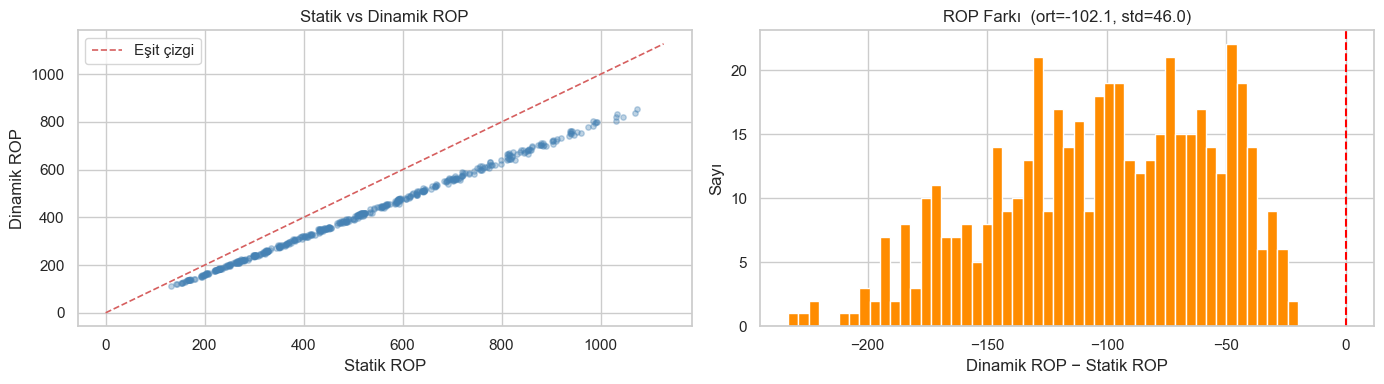

In [6]:
diff = stats['rop_dynamic'] - stats['rop_static']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(stats['rop_static'], stats['rop_dynamic'],
                alpha=0.35, s=15, color='steelblue')
lim = max(stats['rop_static'].max(), stats['rop_dynamic'].max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.2, label='Eşit çizgi')
axes[0].set_xlabel('Statik ROP')
axes[0].set_ylabel('Dinamik ROP')
axes[0].set_title('Statik vs Dinamik ROP')
axes[0].legend()

axes[1].hist(diff, bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Dinamik ROP − Statik ROP')
axes[1].set_ylabel('Sayı')
axes[1].set_title(f'ROP Farkı  (ort={diff.mean():.1f}, std={diff.std():.1f})')

plt.tight_layout()
plt.show()

## 4. EOQ — Economic Order Quantity

$$EOQ = \sqrt{\frac{2 \cdot D \cdot S}{H}}$$

Wilson formülü + `scipy.minimize_scalar` ile doğrulama.

In [7]:
def eoq_wilson(annual_demand, ordering_cost=ORDERING_COST, holding_cost=H):
    """Wilson EOQ — skalar veya NumPy dizisi kabul eder."""
    d = np.asarray(annual_demand, dtype=float)
    result = np.where(d > 0,
                      np.sqrt(2 * d * ordering_cost / holding_cost),
                      0.0)
    return float(result) if result.ndim == 0 else result


def total_inventory_cost(Q, D, S=ORDERING_COST, Hc=H, SS=0.0):
    """TC(Q) = (D/Q)*S + (Q/2 + SS)*H"""
    if Q <= 0:
        return np.inf
    return (D / Q) * S + (Q / 2 + SS) * Hc


def eoq_scipy(annual_demand, safety_stock_val):
    """scipy.minimize_scalar ile optimal Q."""
    if annual_demand <= 0:
        return {'eoq_scipy': 0.0, 'min_cost': 0.0}
    result = minimize_scalar(
        fun    = lambda Q: total_inventory_cost(Q, annual_demand,
                                                SS=safety_stock_val),
        bounds = (1, max(annual_demand * 10, 1)),
        method = 'bounded',
    )
    return {'eoq_scipy': result.x, 'min_cost': result.fun}


print(f'H (holding cost/birim/yıl) = {H:.2f} TL')
D_ex = 365 * 50
print(f'Örnek D={D_ex}: Wilson={eoq_wilson(D_ex):.1f}, '
      f'Scipy={eoq_scipy(D_ex, 0)["eoq_scipy"]:.1f}')

H (holding cost/birim/yıl) = 2.00 TL
Örnek D=18250: Wilson=955.2, Scipy=955.2


In [8]:
eoq_records = []
for _, row in stats.iterrows():
    D  = row['total_annual_demand']
    SS = row['safety_stock']
    sc = eoq_scipy(D, SS)
    eoq_records.append({
        'store'          : row['store'],
        'item'           : row['item'],
        'eoq_wilson'     : round(eoq_wilson(D), 2),
        'eoq_scipy'      : round(sc['eoq_scipy'], 2),
        'min_annual_cost': round(sc['min_cost'], 2),
    })

eoq_df = pd.DataFrame(eoq_records)
stats  = stats.merge(eoq_df, on=['store', 'item'])

diff_eoq = (stats['eoq_wilson'] - stats['eoq_scipy']).abs()
print(f'Wilson–Scipy fark maks: {diff_eoq.max():.4f}  (beklenen ≈ 0)')
stats[['store','item','total_annual_demand',
       'eoq_wilson','min_annual_cost']].head(8).round(1)

Wilson–Scipy fark maks: 0.0000  (beklenen ≈ 0)

,store,item,total_annual_demand,eoq_wilson,min_annual_cost
0,1,1,8097.0,636.3,1358.1
1,1,2,21823.0,1044.6,2285.8
2,1,3,13646.0,826.0,1781.5
3,1,4,8078.0,635.5,1355.2
4,1,5,6824.0,584.1,1238.6
5,1,6,21784.0,1043.6,2269.8
6,1,7,21568.0,1038.5,2264.8
7,1,8,28591.0,1195.6,2633.3


### EOQ vs Talep & Toplam Maliyet Eğrisi

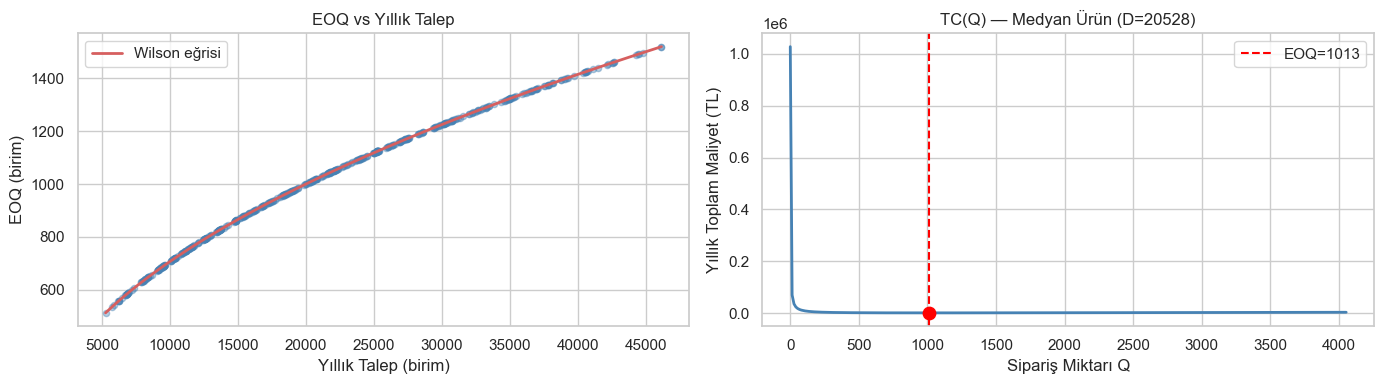

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# EOQ vs yıllık talep
axes[0].scatter(stats['total_annual_demand'], stats['eoq_wilson'],
                alpha=0.4, s=20, color='steelblue')
d_range = np.linspace(stats['total_annual_demand'].min(),
                      stats['total_annual_demand'].max(), 200)
axes[0].plot(d_range, eoq_wilson(d_range), 'r-', lw=2, label='Wilson eğrisi')
axes[0].set_xlabel('Yıllık Talep (birim)')
axes[0].set_ylabel('EOQ (birim)')
axes[0].set_title('EOQ vs Yıllık Talep')
axes[0].legend()

# Toplam maliyet eğrisi — medyan ürün
ex_D   = float(stats['total_annual_demand'].median())
ex_SS  = float(stats['safety_stock'].median())
ex_eoq = eoq_wilson(ex_D)
q_range = np.linspace(1, ex_eoq * 4, 300)
tc = [total_inventory_cost(q, ex_D, SS=ex_SS) for q in q_range]

axes[1].plot(q_range, tc, color='steelblue', lw=2)
axes[1].axvline(ex_eoq, color='red', lw=1.5, linestyle='--',
                label=f'EOQ={ex_eoq:.0f}')
axes[1].scatter([ex_eoq], [total_inventory_cost(ex_eoq, ex_D, SS=ex_SS)],
                s=80, color='red', zorder=5)
axes[1].set_xlabel('Sipariş Miktarı Q')
axes[1].set_ylabel('Yıllık Toplam Maliyet (TL)')
axes[1].set_title(f'TC(Q) — Medyan Ürün (D={ex_D:.0f})')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Çok Amaçlı Optimizasyon: Maliyet + Hizmet Düzeyi

Safety stock, **elde tutma maliyeti** ile **stok tükenme riski** arasında optimum noktayı `scipy.optimize.minimize` (L-BFGS-B) ile bulur:

$$\min_{SS \geq 0} \; \alpha \cdot H \cdot SS + (1-\alpha) \cdot k \cdot \bar{d} \cdot \left[1 - \Phi\!\left(\frac{SS}{\sigma_{LT}}\right)\right]$$

In [10]:
def multi_objective(ss_arr, std_lt, mean_d,
                    alpha=ALPHA, holding=H,
                    stockout_cost=STOCKOUT_COST):
    ss = max(float(ss_arr[0]), 0.0)
    holding_c  = alpha * holding * ss
    p_stockout = (1.0 - norm.cdf(ss / std_lt)) if std_lt > 0 else 0.0
    stockout_c = (1.0 - alpha) * stockout_cost * mean_d * p_stockout
    return holding_c + stockout_c


opt_records = []
for _, row in stats.iterrows():
    std_lt = row['std_lead_time']
    mean_d = row['mean_demand_daily']

    if std_lt > 0:
        res = minimize(
            fun    = lambda ss: multi_objective(ss, std_lt, mean_d),
            x0     = [row['safety_stock']],
            method = 'L-BFGS-B',
            bounds = [(0, std_lt * 10)],
        )
        opt_ss = max(float(res.x[0]), 0.0)
    else:
        opt_ss = 0.0

    opt_records.append({
        'store'           : row['store'],
        'item'            : row['item'],
        'opt_safety_stock': round(opt_ss, 2),
        'opt_rop'         : round(mean_d * LEAD_TIME_DAYS + opt_ss, 2),
    })

stats = stats.merge(pd.DataFrame(opt_records), on=['store', 'item'])

print('Çok amaçlı optimizasyon tamamlandı.')
stats[['store','item','safety_stock','opt_safety_stock',
       'rop_dynamic','opt_rop']].head(8).round(2)

Çok amaçlı optimizasyon tamamlandı.


,store,item,safety_stock,opt_safety_stock,rop_dynamic,opt_rop
0,1,1,42.79,34.85,159.49,190.13
1,1,2,98.33,83.55,418.75,502.08
2,1,3,64.73,54.28,257.74,315.98
3,1,4,42.09,34.41,159.51,189.33
4,1,5,35.17,28.84,136.43,159.71
5,1,6,91.24,78.97,396.19,496.74
6,1,7,93.96,80.53,405.50,494.16
7,1,8,121.01,104.46,535.94,652.78


## 6. Mevcut Stok Simülasyonu

Gerçek stok verisi olmadığından son 30 günlük ortalama satış × rastgele katsayı ile simüle edilir. Gerçek projede ERP/WMS'den okunur.

In [11]:
np.random.seed(42)

last30 = (
    pred_df[pred_df['date'] >= pred_df['date'].max() - pd.Timedelta(days=29)]
    .groupby(['store', 'item'])['sales']
    .mean()
    .reset_index()
    .rename(columns={'sales': 'avg_last30'})
)
last30['stock_ratio']   = np.random.uniform(0.5, 3.0, size=len(last30))
last30['current_stock'] = (last30['avg_last30'] * last30['stock_ratio']).round().astype(int)

stats = stats.merge(last30[['store', 'item', 'current_stock']], on=['store', 'item'])

print('Simüle edilmiş mevcut stok eklendi.')
stats[['store','item','mean_demand_daily','current_stock',
       'safety_stock','rop_dynamic']].head(8).round(2)

Simüle edilmiş mevcut stok eklendi.


,store,item,mean_demand_daily,current_stock,safety_stock,rop_dynamic
0,1,1,22.18,25,42.79,159.49
1,1,2,59.79,136,98.33,418.75
2,1,3,37.39,65,64.73,257.74
3,1,4,22.13,32,42.09,159.51
4,1,5,18.70,13,35.17,136.43
5,1,6,59.68,42,91.24,396.19
6,1,7,59.09,29,93.96,405.50
7,1,8,78.33,160,121.01,535.94


## 7. Aksiyon Önerisi Üretimi

| Aksiyon | Koşul |
|---------|-------|
| `CRITICAL` | `stock < SS` |
| `LOW` | `SS ≤ stock < ROP` |
| `OK` | `ROP ≤ stock ≤ ROP + 2×EOQ` |
| `OVERSTOCK` | `stock > ROP + 2×EOQ` |

Aksiyon dağılımı:
action
CRITICAL    323
LOW         177
Name: count, dtype: int64


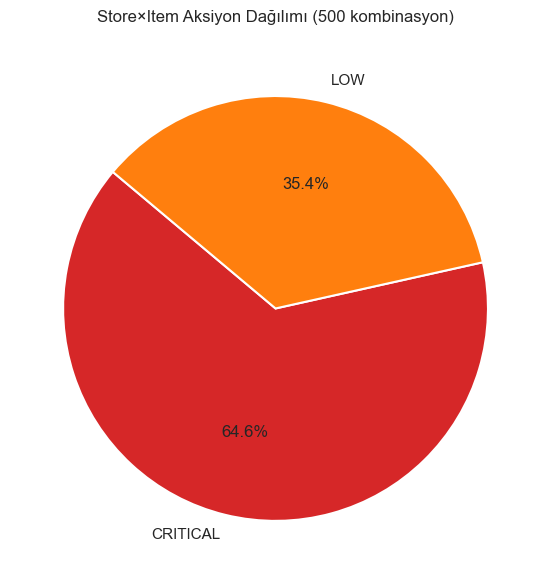

In [12]:
def classify_action(row):
    s, ss, rop, eoq = (row['current_stock'], row['safety_stock'],
                       row['rop_dynamic'],   row['eoq_wilson'])
    if s < ss:
        return 'CRITICAL'
    elif s < rop:
        return 'LOW'
    elif s <= rop + 2 * eoq:
        return 'OK'
    return 'OVERSTOCK'


def order_quantity(row):
    """CRITICAL/LOW → EOQ; diğerleri → 0."""
    return row['eoq_wilson'] if row['action'] in ('CRITICAL', 'LOW') else 0.0


def days_to_reorder(row):
    """Mevcut net stok / günlük talep."""
    d = row['mean_demand_daily']
    if d <= 0:
        return np.inf
    return round((row['current_stock'] - row['safety_stock']) / d, 1)


stats['action']          = stats.apply(classify_action, axis=1)
stats['order_qty']       = stats.apply(order_quantity, axis=1).round(1)
stats['days_to_reorder'] = stats.apply(days_to_reorder, axis=1)

print('Aksiyon dağılımı:')
print(stats['action'].value_counts())

ACTION_COLORS = {'CRITICAL': '#d62728', 'LOW': '#ff7f0e',
                 'OK': '#2ca02c', 'OVERSTOCK': '#9467bd'}
counts = stats['action'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(counts.values,
       labels=counts.index,
       colors=[ACTION_COLORS[a] for a in counts.index],
       autopct='%1.1f%%', startangle=140,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Store×Item Aksiyon Dağılımı (500 kombinasyon)', pad=15)
plt.tight_layout()
plt.show()

## 8. Öncelik Sıralaması & En Kritik Ürünler

In [13]:
priority_map = {'CRITICAL': 4, 'LOW': 3, 'OVERSTOCK': 2, 'OK': 1}
stats['priority_score'] = (
    stats['action'].map(priority_map) * 1000
    + stats['mean_demand_daily']
    - stats['days_to_reorder'].clip(lower=-999)
)

ranked = stats.sort_values('priority_score', ascending=False)

DISPLAY_COLS = ['store', 'item', 'action', 'current_stock',
                'safety_stock', 'rop_dynamic', 'eoq_wilson',
                'order_qty', 'days_to_reorder', 'mean_demand_daily']

critical_low = ranked[ranked['action'].isin(['CRITICAL', 'LOW'])][DISPLAY_COLS].head(20)

print(f'=== EN KRİTİK {len(critical_low)} ÜRÜN ===')
display(
    critical_low.round(1).style.applymap(
        lambda v: ('background-color: #ffcccc' if v == 'CRITICAL'
                   else 'background-color: #ffe5b4' if v == 'LOW' else ''),
        subset=['action']
    )
)

=== EN KRİTİK 20 ÜRÜN ===


,store,item,action,current_stock,safety_stock,rop_dynamic,eoq_wilson,order_qty,days_to_reorder,mean_demand_daily
77,2,28,CRITICAL,65,188.800000,852.800000,1518.800000,1518.800000,-1.000000,126.400000
64,2,15,CRITICAL,116,185.400000,837.200000,1519.000000,1519.000000,-0.500000,126.400000
377,8,28,CRITICAL,51,178.300000,819.600000,1491.400000,1491.400000,-1.000000,121.900000
362,8,13,CRITICAL,145,172.400000,798.300000,1460.200000,1460.200000,-0.200000,116.800000
71,2,22,CRITICAL,89,166.800000,777.600000,1451.000000,1451.000000,-0.700000,115.400000
371,8,22,CRITICAL,46,164.500000,745.400000,1427.200000,1427.200000,-1.100000,111.600000
374,8,25,CRITICAL,56,163.700000,764.000000,1424.900000,1424.900000,-1.000000,111.200000
387,8,38,CRITICAL,83,160.200000,753.400000,1425.500000,1425.500000,-0.700000,111.400000
57,2,8,CRITICAL,86,161.500000,752.900000,1423.300000,1423.300000,-0.700000,111.000000
85,2,36,CRITICAL,111,161.100000,763.600000,1424.600000,1424.600000,-0.500000,111.200000


## 9. Mağaza × Ürün Aksiyon Isı Haritası

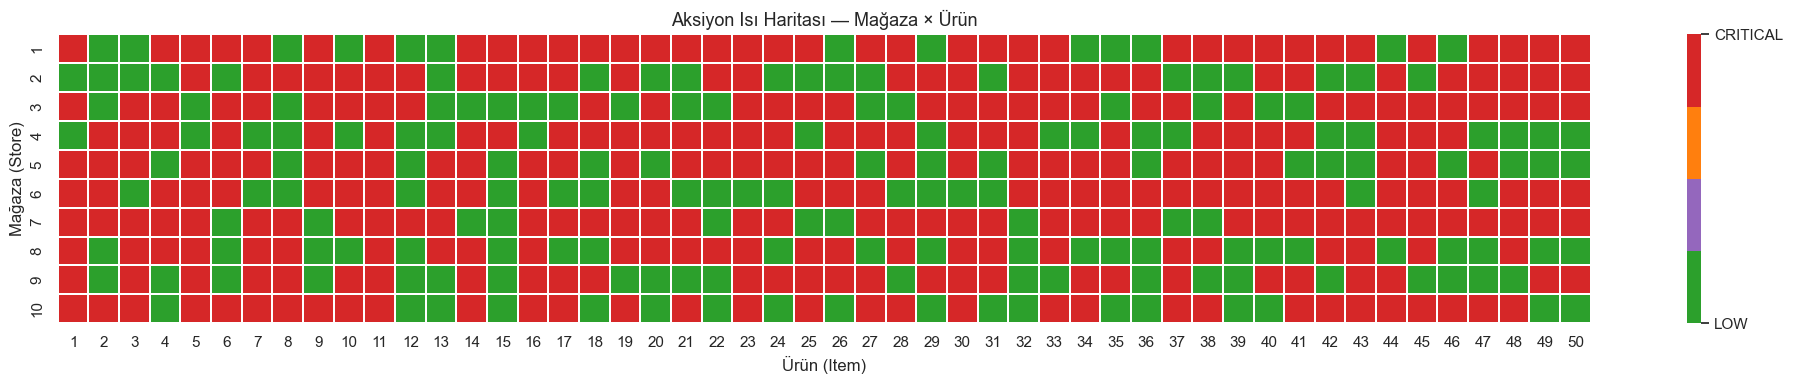

In [14]:
heat_vals = {'OK': 0, 'OVERSTOCK': 1, 'LOW': 2, 'CRITICAL': 3}
pivot = stats.pivot(index='store', columns='item', values='action').replace(heat_vals)

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(
    pivot,
    cmap=['#2ca02c', '#9467bd', '#ff7f0e', '#d62728'],
    linewidths=0.3, linecolor='white',
    cbar_kws={'ticks': [0, 1, 2, 3]},
    ax=ax,
)
ax.collections[0].colorbar.set_ticklabels(['OK', 'OVERSTOCK', 'LOW', 'CRITICAL'])
ax.set_title('Aksiyon Isı Haritası — Mağaza × Ürün', fontsize=13)
ax.set_xlabel('Ürün (Item)')
ax.set_ylabel('Mağaza (Store)')
plt.tight_layout()
plt.show()

## 10. Duyarlılık Analizi: Hizmet Düzeyi

,service_level,z,avg_ss,avg_rop,total_holding_cost
0,0.80,0.84,47.49,459.20,47492.69
1,0.85,1.04,58.49,470.19,58485.94
2,0.90,1.28,72.32,484.02,72317.96
3,0.95,1.64,92.82,504.52,92819.10
4,0.97,1.88,106.13,517.84,106133.19
5,0.99,2.33,131.28,542.98,131275.82


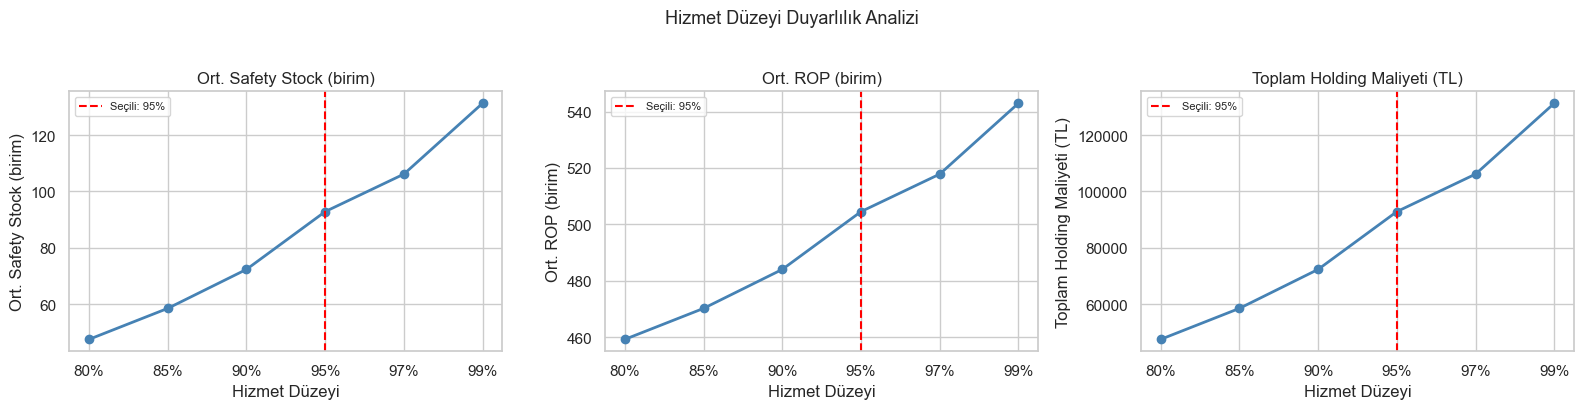

In [15]:
service_levels = [0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
sens_rows = []

for sl in service_levels:
    z_sl    = norm.ppf(sl)
    ss_vals = stats['std_demand_daily'] * z_sl * np.sqrt(LEAD_TIME_DAYS + REVIEW_PERIOD)
    sens_rows.append({
        'service_level'      : sl,
        'z'                  : z_sl,
        'avg_ss'             : ss_vals.mean(),
        'avg_rop'            : (stats['mean_demand_daily'] * LEAD_TIME_DAYS + ss_vals).mean(),
        'total_holding_cost' : (ss_vals * H).sum(),
    })

sens_df = pd.DataFrame(sens_rows)
display(sens_df.round(2))

sl_labels = [f'{s:.0%}' for s in sens_df['service_level']]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, ylabel in [
    (axes[0], 'avg_ss',             'Ort. Safety Stock (birim)'),
    (axes[1], 'avg_rop',            'Ort. ROP (birim)'),
    (axes[2], 'total_holding_cost', 'Toplam Holding Maliyeti (TL)'),
]:
    ax.plot(sl_labels, sens_df[col], marker='o', color='steelblue', lw=2)
    selected_idx = service_levels.index(SERVICE_LEVEL)
    ax.axvline(sl_labels[selected_idx], color='red', lw=1.5,
               linestyle='--', label=f'Seçili: {SERVICE_LEVEL:.0%}')
    ax.set_xlabel('Hizmet Düzeyi')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.suptitle('Hizmet Düzeyi Duyarlılık Analizi', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 11. Sonuçları Kaydet

In [16]:
OUTPUT_COLS = [
    'store', 'item',
    'mean_demand_daily', 'std_demand_daily', 'total_annual_demand',
    'safety_stock', 'opt_safety_stock',
    'rop_static', 'rop_dynamic', 'opt_rop',
    'eoq_wilson', 'eoq_scipy', 'min_annual_cost',
    'current_stock',
    'action', 'order_qty', 'days_to_reorder',
    'priority_score',
]

rec_df = (
    stats[OUTPUT_COLS]
    .sort_values(['action', 'days_to_reorder'], ascending=[True, True])
    .reset_index(drop=True)
)

parquet_path = PROCESSED_DIR / 'inventory_recommendations.parquet'
csv_path     = PROCESSED_DIR / 'inventory_recommendations.csv'

rec_df.to_parquet(parquet_path, index=False)
rec_df.round(2).to_csv(csv_path, index=False)

print(f'Parquet : {parquet_path}  ({parquet_path.stat().st_size / 1e3:.0f} KB)')
print(f'CSV     : {csv_path}  ({csv_path.stat().st_size / 1e3:.0f} KB)')
print(f'\nToplam {len(rec_df)} öneri.')
print('\nAksiyon özeti:')
print(rec_df['action'].value_counts().to_string())

Parquet : ../data/processed/inventory_recommendations.parquet  (56 KB)
CSV     : ../data/processed/inventory_recommendations.csv  (55 KB)

Toplam 500 öneri.

Aksiyon özeti:
action
CRITICAL    323
LOW         177


## 12. Özet

| Bileşen | Yöntem |
|---------|--------|
| **Safety Stock** | $z \cdot \sigma_d \cdot \sqrt{L+R}$ |
| **ROP (Statik)** | $\bar{d} \cdot L + SS$ |
| **ROP (Dinamik)** | $\sum_{t}^{L} \hat{d}_t + SS$ — LightGBM tahmini |
| **EOQ** | Wilson + `scipy.minimize_scalar` doğrulama |
| **Opt. SS** | `scipy.minimize` L-BFGS-B — maliyet & stok tükenme ödünleşimi |
| **Aksiyon** | `CRITICAL / LOW / OK / OVERSTOCK` |

**Kaydedilen dosyalar:**
- `data/processed/inventory_recommendations.parquet`
- `data/processed/inventory_recommendations.csv`

Sonraki adım → `src/services/inventory_service.py` ile FastAPI endpoint'e bağlama.